# Testing out Semantic Embeddings and Chunking

In [1]:
import torch.nn.functional as F
from torch import Tensor
import torch

from sentence_transformers import SentenceTransformer

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders.csv_loader import CSVLoader

import pandas as pd
import numpy as np

/opt/homebrew/caskroom/miniforge/base/envs/AML/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
path_to_csv = "/Users/ingaschoyen/AML_wrapper/AML/data/page_extraction_orig.csv"

## Steps

- loaded raw text extracted using OCR with pandas
- stored text in list to read into encoding model - e5-small-trm-nl
- ! read unfiltered text - caused error bc of float in input
    - allowed datatypes: str, dict, PIL.Image.Image, np.ndarray, torch.Tensor
    - tried again with convert_to_tensor=True - same error at 2m 2.6s running time

- filter text to convert all into string
- computed similarity with all docs vs 

## process data

In [ ]:


def gen_embeddings(model, text):
    embeddings = []
    for t in text:
        embeddings.append(model.encode(t, convert_to_tensor=True))
    return embeddings

def merge_embeddings(embeddings, type="mean"):
    if type == "mean":
        return torch.mean(torch.stack(embeddings), dim=0)
    elif type == "weighted_mean":
        # implement weighted mean if needed
        pass
    else:        
        raise ValueError("Unsupported merge type")

def comp_sim_files(model, embeddings):
    return model.similarity(embeddings, embeddings)

def comp_sim_query(model, query_embedding, embeddings):
    return model.similarity(query_embedding, embeddings)

def load_files(path_to_csv, model, merge_type="mean"):
    df_file, df_page = process_text(path_to_csv)
    
    # generate embeddings for file and page text
    file_embeddings = gen_embeddings(model, df_file['text_sep'])
    page_embeddings = gen_embeddings(model, df_page['text_sep'])
    
    # merge file embeddings into document embedding
    document_embeddings = merge_embeddings(file_embeddings, type=merge_type)
    

    
    return 
    

In [181]:
# print(df['file_id'].unique()) # 1476 unique file ids
# print(df['file_name'].unique()) # 1460 unique file names !! less than file_ids
# print(df['page_number'].max()) # max page number is 242

In [26]:
def process_text(path_to_csv: str):
    # load data
    df_in = pd.read_csv(path_to_csv)
    df_in['text_sep'] = df_in['raw_text'].str.split("\n")
    print(df_in.head())
    # split text into list of strings (split by new line)
    df_out = df_in[['file_id', 'file_name', 'text_sep']].groupby("file_id") #["text_sep"].apply(list).reset_index(name="text_sep")
    
    return df_out

df_out = process_text(path_to_csv)

print(df_out.head())

       file_id                    file_name file_type  page_number  \
0  file_000001  338001_IR_2017_Versie 1.pdf       pdf          1.0   
1  file_000001  338001_IR_2017_Versie 1.pdf       pdf          2.0   
2  file_000001  338001_IR_2017_Versie 1.pdf       pdf          3.0   
3  file_000001  338001_IR_2017_Versie 1.pdf       pdf          4.0   
4  file_000001  338001_IR_2017_Versie 1.pdf       pdf          5.0   

  extraction_method                                           raw_text  \
0   direct_pdf_text  Kunstwerknummer\n338001\nKunstwerktype\nViaduc...   
1   direct_pdf_text  NEN conditiescores\n1 = in uitstekende conditi...   
2   direct_pdf_text  Geconstateerde gebreken\nDilatatievoegovergang...   
3   direct_pdf_text  Schadenummer\n1\nSoort gebrek\nAfwerking\nGebr...   
4   direct_pdf_text  Schadenummer\n2\nSoort gebrek\nAfwerking\nGebr...   

   text_length   status error_message  \
0          581  success           NaN   
1         1115  success           NaN   
2          

In [22]:
print(df_out.head())

                                                      text_sep
file_id                                                       
file_000001  [[Kunstwerknummer, 338001, Kunstwerktype, Viad...
file_000002  [[Kunstwerknummer, 338001, Kunstwerktype, Viad...
file_000003  [[Objectcode 338001, Beheergegevens kunstwerk,...
file_000004                                              [nan]
file_000005  [[02-12-2025, , Wegnummer: _ N338 Meetdatum:, ...


## Load Model and comp embeddings

In [196]:
# loading model from hugging face
model = SentenceTransformer("clips/e5-small-trm-nl")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4188.49it/s]


In [220]:
file_text = df_file['text_sep']
page_text = df_page['text_sep']

In [224]:
type(file_text)

pandas.Series

In [252]:
test = [0, 1, 2, 3]
test_1 = torch.stack((test), dim=2)
print(test_1.shape)

TypeError: expected Tensor as element 0 in argument 0, but got int

In [245]:
file_embeddings = []
for i, text in df_file['text_sep']:
    text_embeddings = []
    for t in text:
        text_embeddings.append(model.encode(t, convert_to_tensor=True))
    acc_text_embeddings = torch.stack(text_embeddings)
    print(acc_text_embeddings.shape)
    page_embeddings[]
    file_embeddings.append(acc_text_embeddings.mean(dim=0)) # average the text embeddings for each file
assert len(file_embeddings) == len(df_file)
df_file['embedding'] = file_embeddings

torch.Size([22, 384])
torch.Size([22, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([8, 384])
torch.Size([8, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([12, 384])
torch.Size([12, 384])
torch.Size([20, 384])
torch.Size([2, 384])
torch.Size([29, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.Size([1, 384])
torch.S

In [244]:
print(df_file['embedding'])

0       [tensor(0.0128, device='mps:0', dtype=torch.bf...
1       [tensor(0.0128, device='mps:0', dtype=torch.bf...
2       [tensor(0.0128, device='mps:0', dtype=torch.bf...
3       [tensor(0.0128, device='mps:0', dtype=torch.bf...
4       [tensor(0.0128, device='mps:0', dtype=torch.bf...
                              ...                        
1471    [tensor(0.0128, device='mps:0', dtype=torch.bf...
1472    [tensor(0.0128, device='mps:0', dtype=torch.bf...
1473    [tensor(0.0128, device='mps:0', dtype=torch.bf...
1474    [tensor(0.0128, device='mps:0', dtype=torch.bf...
1475    [tensor(0.0128, device='mps:0', dtype=torch.bf...
Name: embedding, Length: 1476, dtype: object


In [ ]:
page_embeddings = []
for text in df_page['text_sep']:
    page_embeddings.append(model.encode(text, convert_to_tensor=True))

df_page['embedding'] = page_embeddings

In [ ]:
# print(file_embeddings.shape)
print(page_embeddings.shape)

torch.Size([3967, 384])


In [ ]:
queries = ["beheerobject", "gps"]
query_embeddings = model.encode(queries, convert_to_tensor=True)

## comp similarity

In [ ]:
similarities = model.similarity(query_embeddings, df_file['embedding'].tolist())
print(similarities.shape)

torch.Size([2, 3967])


In [43]:
import numpy as np
import matplotlib.pyplot as plt

In [45]:
sims_1 = []
sims_2 = []
for i in np.linspace(0, 1, 20):
    threshold = i
    sim_1 = [i for i, sim in enumerate(similarities[0]) if sim > threshold]
    sim_2 = [i for i, sim in enumerate(similarities[1]) if sim > threshold]
    sims_1.append(sim_1)
    sims_2.append(sim_2)

Threshold: 0.0
Threshold: 0.05263157894736842
Threshold: 0.10526315789473684
Threshold: 0.15789473684210525
Threshold: 0.21052631578947367
Threshold: 0.2631578947368421
Threshold: 0.3157894736842105
Threshold: 0.3684210526315789
Threshold: 0.42105263157894735
Threshold: 0.47368421052631576
Threshold: 0.5263157894736842
Threshold: 0.5789473684210527
Threshold: 0.631578947368421
Threshold: 0.6842105263157894
Threshold: 0.7368421052631579
Threshold: 0.7894736842105263
Threshold: 0.8421052631578947
Threshold: 0.894736842105263
Threshold: 0.9473684210526315
Threshold: 1.0


In [53]:
similarities = np.stack([np.array([len(sim) for sim in sims_1]), np.array([len(sim) for sim in sims_2])], axis=1)
print(similarities.shape)

(20, 2)


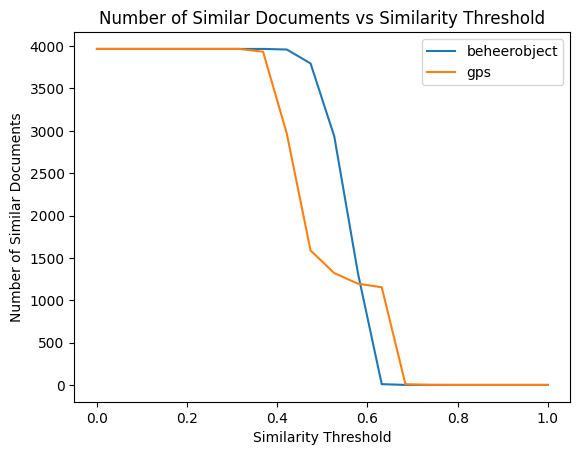

In [60]:
plt.plot(np.linspace(0,1, 20), similarities[:, 0], label="beheerobject")
plt.plot(np.linspace(0,1, 20), similarities[:, 1], label="gps")
plt.xlabel("Similarity Threshold")
plt.ylabel("Number of Similar Documents")
plt.title("Number of Similar Documents vs Similarity Threshold")
plt.legend()
plt.show()

In [ ]:
doc_cov = model.similarity(df_file['embedding'].tolist(), df_page['embedding'].tolist())

In [64]:
print(doc_cov.shape)

torch.Size([3967, 3967])


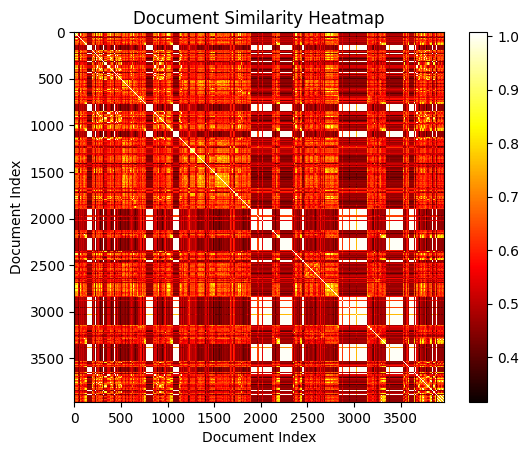

In [68]:
plot = plt.imshow(doc_cov.cpu().detach().float().numpy(), cmap='hot', interpolation='nearest')
plt.colorbar(plot)
plt.title("Document Similarity Heatmap")
plt.xlabel("Document Index")
plt.ylabel("Document Index")
plt.show()  

## Try out some chunking

## Plan

- loop over different splitters and add chunks to respective row in df
- compute overall similarity of all chunks - make graph to show which doc they belong to
- compute average similarity of chunks for given doc - make heatmap

In [77]:
# initialise text splitters
paragraph_splitter = RecursiveCharacterTextSplitter(separators=["\n\n"], chunk_size=1000, chunk_overlap=0)
sentence_splitter = RecursiveCharacterTextSplitter(separators=[". ", "? ", "! "], chunk_size=500, chunk_overlap=0)
line_splitter = RecursiveCharacterTextSplitter(separators=["\n"], chunk_size=500, chunk_overlap=0)

## Using loader for text input

In [ ]:
# collect all raw_text for file_id and save in 

In [123]:
# use langchain loader to load text into doc

loader = CSVLoader(file_path="/Users/ingaschoyen/AML_wrapper/AML/data/page_extraction_orig.csv", 
                   source_column="raw_text",
                   encoding="utf-8")